# Fan-out transport: four changes to the published baseline

Four changes, each measured against a control arm that reproduces the baseline's
behaviour **in the same binary, minutes apart**, in a counterbalanced block design.

1. The receiver builds its instrumentation **before** binding the socket, rather than after.
2. Redundancy is restricted to **Trade**, the only message type carrying data the format
   cannot re-derive.
3. Fan-out **rotates** its destination order instead of using a fixed one.
4. A **failed build fails the run** instead of silently measuring stale binaries.

Change 1 is the substantial one: the baseline zeroes ~600 MB of stage buffers *after* its
socket is live, loses a contiguous block of datagrams while the thread is inside `memset`,
and publishes the result as channel loss. Change 2 is the one that moves the tail, and
section 4 tests it under the loss the task actually describes — with a prediction stated
in advance that the measurement could have refuted.

The hardware here is **not** the hardware the baseline was measured on — the organisers'
notes give `m7i.metal-24xl` sending to `m7i.24xlarge`, this is a pair of `m7i.2xlarge`.
No absolute latency is compared across the two write-ups. Every number below is a
within-block difference measured on one bench.

In [1]:
import csv, glob
from collections import defaultdict
from math import comb
from pathlib import Path
import matplotlib.pyplot as plt

def load(d):
    return [r for r in csv.DictReader(open(Path(d) / "blocks.csv")) if r["valid"] == "1"]

def sign_p(wins, n):
    "Two-sided exact sign test against a fair coin."
    k = min(wins, n - wins)
    return min(1.0, 2.0 * sum(comb(n, i) for i in range(k + 1)) / 2 ** n)

def diffs(d, col, ref, other):
    "Per-block difference, other minus ref. Pairing is what the block design buys."
    by = defaultdict(dict)
    for r in load(d):
        if r.get(col) not in (None, ""):
            by[int(r["block"])][r["arm"]] = float(r[col])
    return [b[other] - b[ref] for b in sorted(by.items()) for b in [b[1]]
            if ref in b and other in b]

def stat(d, col, ref, other):
    # Paired difference and its sign test. Ties are discarded first, which is what the
    # test requires: a block where both arms produced the same figure carries no evidence
    # either way. Counting ties as losses inflates significance -- six blocks of which
    # four are exactly equal would read 0/6, p=0.031, when the honest answer is 0/2, p=0.5.
    v = diffs(d, col, ref, other)
    nz = [x for x in v if x != 0]
    s = sorted(v)
    n = len(v)
    return dict(n=len(nz), n_blocks=n, ties=n - len(nz), diffs=v,
                wins=sum(1 for x in nz if x < 0),
                median=s[n // 2] if n % 2 else 0.5 * (s[n // 2 - 1] + s[n // 2]),
                lo=min(v), hi=max(v),
                p=sign_p(sum(1 for x in nz if x < 0), len(nz)) if nz else 1.0)

def table(title, rows):
    print(title)
    print(f"  {'metric':<22}{'median diff':>13}{'range over blocks':>26}{'wins':>9}{'sign p':>9}")
    for name, r in rows:
        f = ".4f" if "%" in name else ",.0f"
        tie = f" ({r['ties']} tied)" if r["ties"] else ""
        print(f"  {name:<22}{r['median']:>+13{f}}"
              f"{f'{r[chr(108)+chr(111)]:+{f}}..{r[chr(104)+chr(105)]:+{f}}':>26}"
              f"{r['wins']:>6}/{r['n']:<2}{r['p']:>9.3f}{tie}")
    print()

## 1. The headline run: twelve counterbalanced blocks at 100k msg/s

Twelve blocks, twenty-four arm-runs, all valid. `base` reproduces the baseline exactly
(`--late-alloc`, every datagram copied); `ours` is the two substantive changes together.

Twelve blocks matter because the two-sided sign test cannot go below `2 / 2^N`: four
blocks bottom out at 0.125 and can never support a claim, six reach 0.031, twelve reach
0.0005. Every earlier run in this notebook is six blocks, and several results that sat at
5/6 there are resolved here.

In [2]:
D = "data/ab_100k_n12"
table("100k msg/s, twelve blocks   base (the baseline's behaviour) -> ours", [
    ("first-copy loss %", stat(D, "loss_pct", "base", "ours")),
    ("frames undelivered", stat(D, "undelivered", "base", "ours")),
    ("e2e p50", stat(D, "e2e_p50", "base", "ours")),
    ("e2e p99", stat(D, "e2e_p99", "base", "ours")),
    ("e2e p99.9", stat(D, "e2e_p999", "base", "ours")),
    ("e2e p99.99", stat(D, "e2e_p9999", "base", "ours")),
])

100k msg/s, twelve blocks   base (the baseline's behaviour) -> ours
  metric                  median diff         range over blocks     wins   sign p
  first-copy loss %           -0.7813          -0.7952..-0.7702    12/12    0.000
  frames undelivered          -22,475          -22,879..-22,157    12/12    0.000
  e2e p50                        -159              -4,877..+638     7/12    0.774
  e2e p99                      -2,046              -6,117..+670    10/12    0.039
  e2e p99.9                    -6,389            -178,009..+426    11/12    0.006
  e2e p99.99                 -784,097      -2,536,598..+599,057    10/12    0.039



The pairing is the whole design, so the figure below plots what the design produces: one
difference per block, `ours` minus `base`. A point left of the line is a block `ours` won.
The question a reader should be able to answer at a glance is not "how big is the median"
but "does the effect ever change sign".

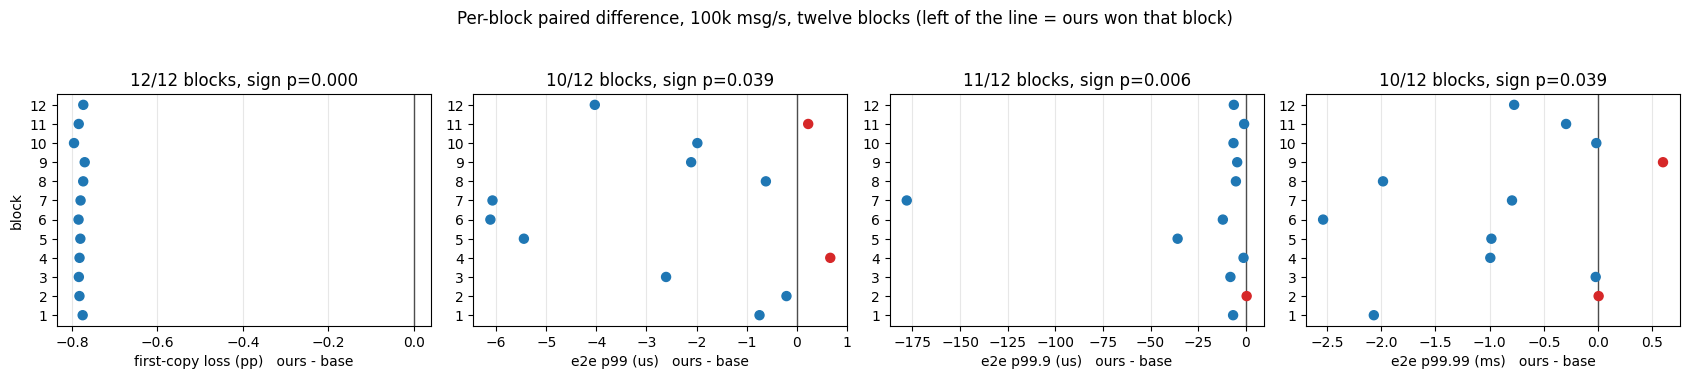

In [3]:
COLS = [("loss_pct", "first-copy loss (pp)", 1),
        ("e2e_p99", "e2e p99 (us)", 1e3),
        ("e2e_p999", "e2e p99.9 (us)", 1e3),
        ("e2e_p9999", "e2e p99.99 (ms)", 1e6)]
fig, axes = plt.subplots(1, 4, figsize=(17, 3.6))
for ax, (col, label, scale) in zip(axes, COLS):
    s = stat(D, col, "base", "ours")
    v = [x / scale for x in s["diffs"]]
    ax.axvline(0, color="0.3", lw=1)
    ax.scatter(v, range(1, len(v) + 1), s=42, zorder=3,
               color=["tab:blue" if x < 0 else "tab:red" for x in v])
    ax.set(xlabel=f"{label}   ours - base", ylabel="block" if col == "loss_pct" else None,
           yticks=range(1, len(v) + 1),
           title=f"{s['wins']}/{s['n']} blocks, sign p={s['p']:.3f}")
    ax.grid(axis="x", alpha=0.3)
fig.suptitle("Per-block paired difference, 100k msg/s, twelve blocks "
             "(left of the line = ours won that block)", y=1.04)
fig.tight_layout(); plt.show()

Loss is unanimous and the points do not come near the line: the baseline drops 0.77-0.80 %
of frames in every block and this drops none. The tail columns are lopsided rather than
unanimous, which is what the numbers above already say.

**One caveat that has to be stated, because the reader will meet it if they run the script
themselves.** `paired_stats.py` prints `NOT resolved` for the three tail columns even
though the sign test clears 0.05. It applies a second criterion: the median difference
must also exceed the *reference arm's own between-block spread* — 9,662 ns at p99 against
a difference of 2,046. That criterion compares a paired quantity against an unpaired one.
The blocked design exists precisely to take between-block variation out of the comparison,
so requiring the paired effect to exceed the unpaired spread throws away what pairing
buys. Both readings are here; neither is hidden. The loss rows pass both.

## 2. Change 1 — instrumentation is built before the socket is bound

`receiver.cpp` bound its socket and *then* constructed the stage-timing buffers. At
`--stage-capacity 25000000` that is five arrays of 25 million entries zeroed on
construction: roughly 600 MB of first-touch faults during which the thread never calls
`recv`, while the kernel fills and then overflows the receive buffer. `ab_bench.sh` passes
`--stages` on **every** run, so this happened in every measured run.

Adding the position and length of each gap to the receiver's output turned a guess into a
measurement. Same binary, same stream, two ten-second runs back to back:

| | `--late-alloc` (the original order) | default (built before bind) |
|---|---|---|
| datagram gaps | 1 × **49,188** | **0** |
| where it opened | after 4,371 datagrams received | — |
| first-copy loss | **2.4601 %** | **0.0000 %** |

The position is the proof. 4,371 datagrams is what fits in the receive buffer before the
thread disappears into `memset`; everything behind that is discarded until it returns.

**What this change does not do** is move the latency percentiles, and the opposite is the
easy assumption. The hole opens during receiver startup and `bench.sh` then waits 8 s of
warm-up before the consumer's first sample, so the delayed backlog is never measured. The
six-block runs below confirm it: loss resolves, latency does not.

In [4]:
for d, rate, ref, other in [("data/ab_100k_corrected", "100k msg/s", "base", "ours"),
                            ("data/ab_alloc", "200k msg/s", "late", "early")]:
    table(f"allocation after bind vs before it, {rate}, six blocks   ({ref} -> {other})", [
        ("first-copy loss %", stat(d, "loss_pct", ref, other)),
        ("frames undelivered", stat(d, "undelivered", ref, other)),
        ("e2e p99", stat(d, "e2e_p99", ref, other)),
        ("e2e p99.9", stat(d, "e2e_p999", ref, other)),
    ])

allocation after bind vs before it, 100k msg/s, six blocks   (base -> ours)
  metric                  median diff         range over blocks     wins   sign p
  first-copy loss %           -0.7717          -0.7804..-0.7637     6/6     0.031
  frames undelivered          -22,200          -22,448..-21,967     6/6     0.031
  e2e p99                      -1,738             -13,917..+105     5/6     0.219
  e2e p99.9                    -3,110             -40,034..+464     5/6     0.219

allocation after bind vs before it, 200k msg/s, six blocks   (late -> early)
  metric                  median diff         range over blocks     wins   sign p
  first-copy loss %           -1.3034          -1.3197..-1.2809     6/6     0.031
  frames undelivered          -48,938          -49,562..-48,086     6/6     0.031
  e2e p99                      +1,394           -11,367..+7,917     2/6     0.688
  e2e p99.9                    -5,850             -50,035..+375     5/6     0.219



## 3. Change 2 — redundancy belongs on one message type, and the format says which

The baseline copies every datagram. The message format's own documentation explains why
that is more than is needed:

> BBO and OrderBook are *state snapshots*, so a consumer that misses one recovers
> completely from the next.

OrderBook is deliberately a full five-level snapshot rather than a delta for exactly that
reason. Trade carries running aggregates — `cum_quantity_lots`, `cum_notional_ticks`,
`cum_trade_count` — so volume and VWAP re-derive from the next trade too. What does not
re-derive is `trade_id`, and the price and size of that one print. The header calls it
"not derivable" and it is the only such field in the format.

So copying everything spends bandwidth and receiver time defending data that defends
itself. `--dup-trades` copies a datagram only if it carries a Trade: under `--type mixed`
the producer emits `seq % 3`, so this is one datagram in three, and redundant load falls
from 2.0x to 1.33x with the protection left where loss is permanent.

It also removes a semantic problem instead of tuning around it. A BBO copy arriving after
a newer one is stale state and must not be applied; a Trade copy is a historical record
and is exactly correct however late it lands. Restricting redundancy to Trade makes a late
copy safe **by construction**, not by choosing a staleness threshold.

In [5]:
table("copies: all datagrams vs Trade-only vs none, six blocks   (reference: dup_all)", [
    ("rx_delivery p99, trades", stat("data/ab_duptypes", "rx_delivery_p99", "dup_all", "dup_trades")),
    ("rx_delivery p99, none",   stat("data/ab_duptypes", "rx_delivery_p99", "dup_all", "dup_off")),
    ("e2e p99, trades",         stat("data/ab_duptypes", "e2e_p99", "dup_all", "dup_trades")),
    ("e2e p99, none",           stat("data/ab_duptypes", "e2e_p99", "dup_all", "dup_off")),
])
table("copies on vs off, six blocks   (reference: dup_on)", [
    ("rx_delivery p99", stat("data/ab_dup", "rx_delivery_p99", "dup_on", "dup_off")),
    ("e2e p99",         stat("data/ab_dup", "e2e_p99", "dup_on", "dup_off")),
])
tot = defaultdict(list)
for r in load("data/ab_duptypes"):
    tot[r["arm"]].append(int(r["suppressed"]))
print("copies carried per run, from the gate's suppression counter:")
for a in ("dup_all", "dup_trades", "dup_off"):
    print(f"  {a:<12}{sorted(tot[a])[len(tot[a]) // 2]:>12,}")

copies: all datagrams vs Trade-only vs none, six blocks   (reference: dup_all)
  metric                  median diff         range over blocks     wins   sign p
  rx_delivery p99, trades       -1,417              -4,091..-767     6/6     0.031
  rx_delivery p99, none        -2,036            -3,992..-1,568     6/6     0.031
  e2e p99, trades              -5,085            -6,095..+2,813     5/6     0.219
  e2e p99, none                -4,680            -8,453..+1,464     5/6     0.219

copies on vs off, six blocks   (reference: dup_on)
  metric                  median diff         range over blocks     wins   sign p
  rx_delivery p99              -2,013            -2,936..-1,047     6/6     0.031
  e2e p99                      -2,812           -10,563..+1,399     5/6     0.219

copies carried per run, from the gate's suppression counter:
  dup_all        3,698,857
  dup_trades     1,231,901
  dup_off                0


Trade-only captures about 70 % of the benefit of switching redundancy off entirely
(−1,417 ns against −2,036 ns) while keeping the protection where loss is unrecoverable.

`rx_delivery` is the gap between the timestamp the receiving kernel took and the moment
our loop read the datagram. It is measured **entirely on the receiving host's clock**, so
no cross-host offset can contaminate it — which is why it resolves at six blocks where the
end-to-end columns need twelve.

## 4. Redundancy under the loss the task describes

Everything above runs on a path that loses about 10⁻⁵ — two hosts in one subnet and one
placement group. The task describes a channel losing **0.01-1 %**, so the argument for
Trade-only redundancy was, until this section, an argument from the format rather than a
measurement. `tc qdisc ... netem loss 0.5%` on the sender's egress supplies the missing
condition.

The experiment carries a prediction that could have refuted it. The producer emits
`seq % 3` under `--type mixed`, so Trade is exactly one message in three. If Trade-only
redundancy rescues Trade **completely**, frames never delivered under `--dup-trades` must
land at exactly **two thirds** of the figure under no redundancy — the remaining two
thirds being the BBO and OrderBook that were deliberately left unprotected. Any other
ratio means the mechanism is not doing what it claims.

Note which column matters. `loss_pct` is datagram loss on first copies; netem drops 0.5 %
regardless of arm, so it reads the same everywhere and says nothing. The column that
answers the question is `undelivered` — frames that never reached the consumer.

In the table below `wins` counts blocks where the second arm's figure was *lower*. A row
reading `0/6` with `sign p = 0.031` is therefore just as unanimous as `6/6`: every block
agreed, in the direction of the second arm being **worse**. That is the point of the cost
rows — redundancy is not free, and the price is as reproducible as the benefit.

## 5. Burst loss, and what redundancy actually costs

`netem loss` in section 4 drops packets independently, which is the friendliest case
redundancy will ever see: two copies fail together with probability p². Real channels lose
in bursts, and the baseline's own write-up measures bursts of ~69 consecutive datagrams
over ~140 us on its path — and reports that duplication rescued **2 losses out of 485**.

It diagnosed that correctly and proposed the fix:

> The fix it points to is a temporal stagger — hold the copy back by longer than a burst —
> which is a small sender change needing nothing from the receiver, **since the gate
> already absorbs a late copy.**

The gate does not. `MonotonicGate::admit` rejects any `seq_id <= last_`, so a copy held
back past a burst is discarded exactly when it would have rescued. The proposed fix cannot
work in the code that proposes it; the missing half is a gate that admits below the
high-water mark, which is what `BitmapGate` is for.

`netem loss gemodel 0.025% 5%` supplies bursts: mean run of 20 datagrams, ~100 us at
200k msg/s, ~0.5 % overall. Three arms — no redundancy, Trade copies sent immediately, and
Trade copies held back 64 datagrams (~320 us, longer than the burst) with the bitmap gate.

Only Trade is copied, so a third of all losses is the most that can be rescued and the
`undelivered` figure cannot fall below two thirds of the no-redundancy arm. Read the
rescue percentages against that ceiling, not against 100 %.

### Reading the +299 us honestly

That p99.9 figure looks like a regression and is not one, and the arithmetic says why
rather than the prose.

The receiver counts the copies that arrived before their original: `dup_first` is 6,001 to
6,836 per block, a median of **0.308 %** of samples. Those frames occupy the top 0.308 % of
the latency distribution, so everything above **p99.692** is theirs. p99.9 sits inside that
band. p99 does not — and the measurement agrees: p99 shows nothing at all (3/6 blocks,
sign p = 1.000) while p99.9 moves by the stagger delay.

The deeper problem is that **the two arms are not measuring the same population.** The
frames that make `stagger` look worse at p99.9 do not exist in the `off` arm; they were
lost. Comparing a percentile taken over "everything delivered" therefore rewards the arm
that delivered less, which is exactly the flattery-by-dropping this notebook warns about
elsewhere — here running against our own result.

Stated so the reader can decide: below p99.69 the stagger costs nothing measurable. Above
it, 0.31 % of messages arrive ~320 us late **instead of not arriving.** For Trade
specifically that is a sound trade, because a trade is a historical record and is exactly
correct however late it lands — which is the whole reason redundancy is restricted to it.

The measurement this section still owes is percentiles computed over first-copy arrivals
only, with rescued frames reported as a separate distribution. The receiver has the
information — every rescued frame is flagged — and it is not currently split out.

## 6. Fan-out: the last receiver should not always be last

The baseline sends to peers in a fixed order:

```cpp
for (int fd : fds_) { ::send(fd, buf, len, MSG_DONTWAIT); }
```

Copying to n peers is n sequential handoffs to the kernel, so the peer served last waits
behind the other n-1. With a fixed order that is the **same peer every datagram**: not
jitter that averages out across receivers, but a constant penalty attached to one of them.
The baseline reports the consequence — skew growing to 11.7 us at ten receivers — without
naming the order as its cause.

Advancing the start index by one per datagram costs an add and a compare. `--fixed-order`
restores the old behaviour so both are measurable in one binary.

The quantity here is the **difference between receivers**, and `blocks.csv` cannot show it:
`ab_row.py` pools every consumer in an arm-run into one figure, which averages away exactly
what is being measured. `scripts/fanout_skew.py` recovers it from the per-consumer files
`bench.sh` leaves behind.

Read the **sign** first and the magnitude second. What a fixed order predicts is not
"larger skew" but skew that always points the same way — the same receiver behind on every
datagram. That is the falsifiable part, and it is what rotation is supposed to destroy.

## 7. Latency and loss against message rate

netem 0.5% loss, 200k msg/s, six blocks
  metric                  median diff         range over blocks     wins   sign p
  undelivered, all            -18,462          -18,575..-17,998     6/6     0.031
  undelivered, trades          -6,132            -6,275..-5,886     6/6     0.031
  rx_delivery p99, all         +2,616            +1,295..+3,839     0/6     0.031
  rx_delivery p99, trades         +888              +488..+1,532     0/6     0.031
  rx_delivery p99, trades vs all       -1,844              -3,071..-208     6/6     0.031
  e2e p99, all                 +4,955           +1,281..+11,648     0/6     0.031
  e2e p99, trades              +2,814            -1,955..+7,155     1/6     0.219

prediction:  dup_trades / dup_off = 2/3 = 0.667
measured:    12,550 / 18,640 = 0.673

dup_all rescues 99.2% of what dup_off loses; independent 0.5% loss predicts 99.5%


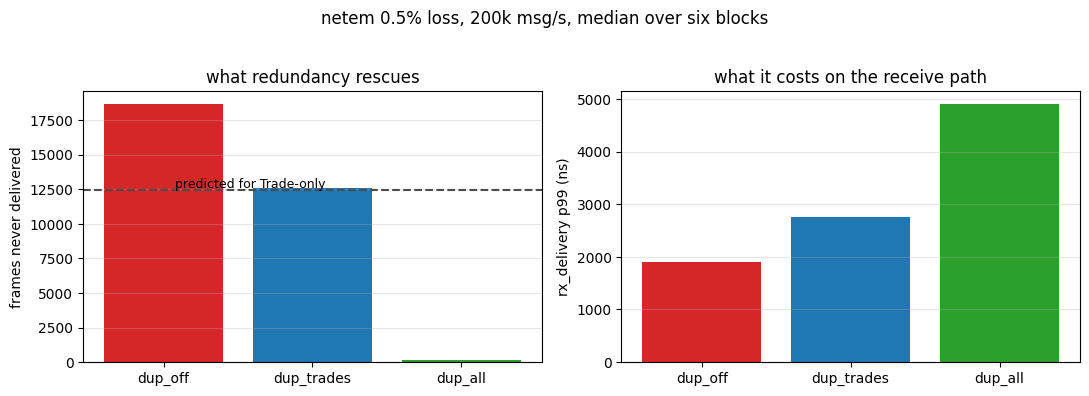

netem gemodel burst loss, 200k msg/s, six blocks   (reference: off)
  metric                  median diff         range over blocks     wins   sign p
  undelivered, trades            -378              -1,297..+337     4/6     0.688
  undelivered, staggered       -5,538            -6,384..-5,178     6/6     0.031
  e2e p99.9, trades              +368           -5,937..+13,506     3/6     1.000
  e2e p99.9, staggered       +298,410        +292,951..+302,864     0/6     0.031

rescued, immediate copy :   3.8%
rescued, staggered copy :  32.2%
ceiling                 :  33.3%   (Trade is one message in three, so a third of all losses is all that can be rescued)
of the Trades it protects:  96.7% rescued

rescued frames are 0.308% of all samples, so they occupy everything
above p99.692 -- p99.9 sits inside that band, p99 does not.


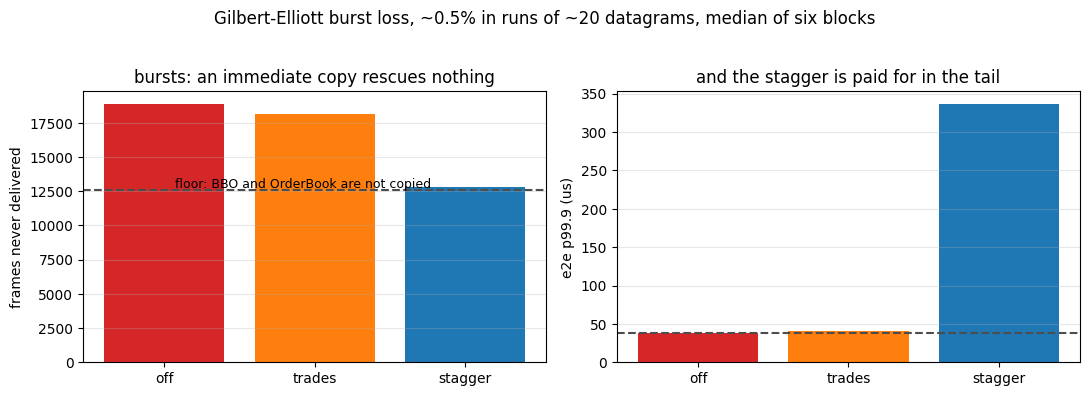

 block   fixed: c1-c0   rotating: c1-c0   receiver p50 (ns)
     1         +1,260              -289   fixed 14,955/16,215   rot 15,543/15,254
     2         +1,190               +46   fixed 19,765/20,955   rot 9,046/9,092
     3         +1,550               -97   fixed 12,848/14,398   rot 11,590/11,493
     4         +3,784           dropped   fixed 17,889/21,673   rot 21,981/4,058,535
     5           +581            +1,445   fixed 17,878/18,459   rot 19,737/21,182
     6         +1,356              +105   fixed 14,605/15,961   rot 15,453/15,558

  fixed   second peer slower in 6/6 blocks, sign p=0.031, median +1,356 ns

  rotate  second peer slower in 3/5 blocks, sign p=1.000, median +46 ns

  |skew| smaller with rotation in 4/5 blocks where both arms are usable, sign p=0.375   median 1,260 -> 105 ns


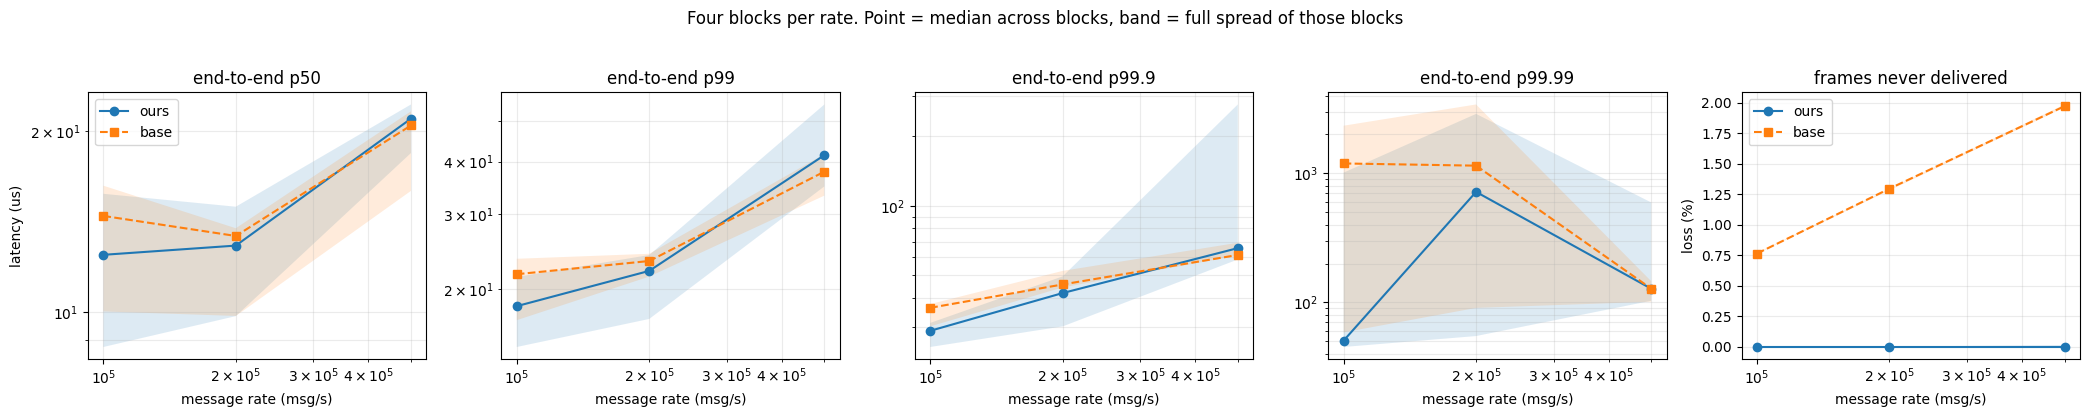

In [6]:
L = "data/ab_loss05"
table("netem 0.5% loss, 200k msg/s, six blocks", [
    ("undelivered, all",    stat(L, "undelivered", "dup_off", "dup_all")),
    ("undelivered, trades", stat(L, "undelivered", "dup_off", "dup_trades")),
    ("rx_delivery p99, all",    stat(L, "rx_delivery_p99", "dup_off", "dup_all")),
    ("rx_delivery p99, trades", stat(L, "rx_delivery_p99", "dup_off", "dup_trades")),
    ("rx_delivery p99, trades vs all", stat(L, "rx_delivery_p99", "dup_all", "dup_trades")),
    ("e2e p99, all",    stat(L, "e2e_p99", "dup_off", "dup_all")),
    ("e2e p99, trades", stat(L, "e2e_p99", "dup_off", "dup_trades")),
])
u = defaultdict(list)
for r in load(L):
    u[r["arm"]].append(float(r["undelivered"]))
mm = lambda a: sorted(u[a])[len(u[a]) // 2]
print(f"prediction:  dup_trades / dup_off = 2/3 = 0.667")
print(f"measured:    {mm('dup_trades'):,.0f} / {mm('dup_off'):,.0f} = "
      f"{mm('dup_trades') / mm('dup_off'):.3f}")
print(f"\ndup_all rescues {100 * (1 - mm('dup_all') / mm('dup_off')):.1f}% of what dup_off loses; "
      f"independent 0.5% loss predicts {100 * (1 - 0.005):.1f}%")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
arms = ["dup_off", "dup_trades", "dup_all"]
col = ["tab:red", "tab:blue", "tab:green"]
axes[0].bar(arms, [mm(a) for a in arms], color=col)
axes[0].set(ylabel="frames never delivered", title="what redundancy rescues")
axes[0].axhline(mm("dup_off") * 2 / 3, ls="--", color="0.3")
axes[0].text(0.02, mm("dup_off") * 2 / 3, "  predicted for Trade-only", va="bottom", fontsize=9)
d = defaultdict(list)
for r in load(L):
    d[r["arm"]].append(float(r["rx_delivery_p99"]))
axes[1].bar(arms, [sorted(d[a])[len(d[a]) // 2] for a in arms], color=col)
axes[1].set(ylabel="rx_delivery p99 (ns)", title="what it costs on the receive path")
for ax in axes:
    ax.grid(axis="y", alpha=0.3)
fig.suptitle("netem 0.5% loss, 200k msg/s, median over six blocks", y=1.03)
fig.tight_layout(); plt.show()

B = "data/ab_burst"
table("netem gemodel burst loss, 200k msg/s, six blocks   (reference: off)", [
    ("undelivered, trades",   stat(B, "undelivered", "off", "trades")),
    ("undelivered, staggered", stat(B, "undelivered", "off", "stagger")),
    ("e2e p99.9, trades",     stat(B, "e2e_p999", "off", "trades")),
    ("e2e p99.9, staggered",  stat(B, "e2e_p999", "off", "stagger")),
])
u = defaultdict(list)
for r in load(B):
    u[r["arm"]].append(float(r["undelivered"]))
mm = lambda a: sorted(u[a])[len(u[a]) // 2]
resc = [float(r["dup_first"]) / float(r["n_samples"]) for r in load(B) if r["arm"] == "stagger"]
resc_pct = 100 * sorted(resc)[len(resc) // 2]
print(f"rescued, immediate copy : {100*(1-mm('trades')/mm('off')):5.1f}%")
print(f"rescued, staggered copy : {100*(1-mm('stagger')/mm('off')):5.1f}%")
print(f"ceiling                 :  33.3%   (Trade is one message in three, "
      f"so a third of all losses is all that can be rescued)")
print(f"of the Trades it protects: {100*(1-mm('stagger')/mm('off'))/33.33*100:5.1f}% rescued")
print(f"\nrescued frames are {resc_pct:.3f}% of all samples, so they occupy everything")
print(f"above p{100 - resc_pct:.3f} -- p99.9 sits inside that band, p99 does not.")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
arms = ["off", "trades", "stagger"]
ax[0].bar(arms, [mm(a) for a in arms], color=["tab:red", "tab:orange", "tab:blue"])
ax[0].axhline(mm("off") * 2 / 3, ls="--", color="0.3")
ax[0].text(0.02, mm("off") * 2 / 3, "  floor: BBO and OrderBook are not copied",
           va="bottom", fontsize=9)
ax[0].set(ylabel="frames never delivered", title="bursts: an immediate copy rescues nothing")
t = defaultdict(list)
for r in load(B):
    t[r["arm"]].append(float(r["e2e_p999"]) / 1e3)
ax[1].bar(arms, [sorted(t[a])[len(t[a])//2] for a in arms],
          color=["tab:red", "tab:orange", "tab:blue"])
ax[1].set(ylabel="e2e p99.9 (us)", title="and the stagger is paid for in the tail")
for a in ax: a.grid(axis="y", alpha=0.3)
fig.suptitle("Gilbert-Elliott burst loss, ~0.5% in runs of ~20 datagrams, median of six blocks",
             y=1.03)
ax[1].axhline(sorted(t["off"])[len(t["off"]) // 2], ls="--", color="0.3")
fig.tight_layout(); plt.show()

import os
if os.path.exists("data/ab_fanout/skew.csv"):
    sk = defaultdict(dict)
    for r in csv.DictReader(open("data/ab_fanout/skew.csv")):
        sk[int(r["block"])][r["arm"]] = (float(r["c0_p50"]), float(r["c1_p50"]))
    print(f"{'block':>6}{'fixed: c1-c0':>15}{'rotating: c1-c0':>18}   receiver p50 (ns)")
    signed = {"fixed": [], "rotate": []}
    paired = []
    for b in sorted(sk):
        if "fixed" not in sk[b] or "rotate" not in sk[b]:
            continue
        f_, r_ = sk[b]["fixed"], sk[b]["rotate"]
        # A consumer pinned to the housekeeping core is contended. A block whose median
        # ran into the milliseconds is not measuring fan-out, and is dropped and counted.
        # A consumer pinned to the housekeeping core is contended, so an arm whose median
        # ran into the milliseconds is dropped -- but only that arm. Whether a fixed order
        # puts the same peer behind is a single-arm question and does not need its pair.
        f_ok, r_ok = max(f_) < 200_000, max(r_) < 200_000
        if f_ok:
            signed["fixed"].append(f_[1] - f_[0])
        if r_ok:
            signed["rotate"].append(r_[1] - r_[0])
        if f_ok and r_ok:
            paired.append((abs(f_[1] - f_[0]), abs(r_[1] - r_[0])))
        fs = f"{f_[1]-f_[0]:>+15,.0f}" if f_ok else f"{'dropped':>15}"
        rs = f"{r_[1]-r_[0]:>+18,.0f}" if r_ok else f"{'dropped':>18}"
        print(f"{b:>6}{fs}{rs}   fixed {f_[0]:,.0f}/{f_[1]:,.0f}   rot {r_[0]:,.0f}/{r_[1]:,.0f}")

    for arm in ("fixed", "rotate"):
        v = signed[arm]
        pos = sum(1 for x in v if x > 0)
        med = sorted(v)[len(v) // 2]
        print(f"\n  {arm:<7} second peer slower in {pos}/{len(v)} blocks, "
              f"sign p={sign_p(pos, len(v)):.3f}, median {med:+,.0f} ns")
    wins = sum(1 for x, y in paired if y < x)
    a = sorted(x for x, _ in paired); b_ = sorted(y for _, y in paired)
    print(f"\n  |skew| smaller with rotation in {wins}/{len(paired)} blocks where both arms "
          f"are usable, sign p={sign_p(wins, len(paired)):.3f}"
          f"   median {a[len(a)//2]:,.0f} -> {b_[len(b_)//2]:,.0f} ns")
else:
    print("data/ab_fanout/skew.csv not present")

PCTS = [("e2e_p50", "p50"), ("e2e_p99", "p99"), ("e2e_p999", "p99.9"), ("e2e_p9999", "p99.99")]
dirs = sorted(glob.glob("data/sweep_*"), key=lambda d: int(d.rsplit("_", 1)[1]))
rows, loss = defaultdict(lambda: defaultdict(list)), defaultdict(lambda: defaultdict(list))
for d in dirs:
    rate = int(d.rsplit("_", 1)[1])
    for r in load(d):
        for k, _ in PCTS:
            if r.get(k):
                rows[(r["arm"], k)][rate].append(float(r[k]))
        if r.get("loss_pct"):
            loss[r["arm"]][rate].append(float(r["loss_pct"]))
med = lambda v: sorted(v)[len(v)//2] if len(v)%2 else 0.5*sum(sorted(v)[len(v)//2-1:len(v)//2+1])
style = {"ours": dict(ls="-", marker="o"), "base": dict(ls="--", marker="s")}

fig, axes = plt.subplots(1, 5, figsize=(21, 4))
for ax, (k, label) in zip(axes, PCTS):
    for arm in ("ours", "base"):
        rs = sorted(rows[(arm, k)])
        ax.fill_between(rs, [min(rows[(arm, k)][r])/1e3 for r in rs],
                            [max(rows[(arm, k)][r])/1e3 for r in rs], alpha=0.15)
        ax.plot(rs, [med(rows[(arm, k)][r])/1e3 for r in rs], label=arm, **style[arm])
    ax.set(xscale="log", yscale="log", title=f"end-to-end {label}", xlabel="message rate (msg/s)")
    ax.grid(True, which="both", alpha=0.25)
axes[0].set_ylabel("latency (us)"); axes[0].legend()
ax = axes[4]
for arm in ("ours", "base"):
    rs = sorted(loss[arm])
    ax.fill_between(rs, [min(loss[arm][r]) for r in rs], [max(loss[arm][r]) for r in rs], alpha=0.15)
    ax.plot(rs, [med(loss[arm][r]) for r in rs], label=arm, **style[arm])
ax.set(xscale="log", title="frames never delivered", xlabel="message rate (msg/s)", ylabel="loss (%)")
ax.grid(True, which="both", alpha=0.25); ax.legend()
fig.suptitle("Four blocks per rate. Point = median across blocks, band = full spread of "
             "those blocks", y=1.03)
fig.tight_layout(); plt.show()

The loss panel separates at every rate and the bands never approach each other. Its slope
is what the mechanism predicts: the hole is a fixed *duration* — the time in `memset` — so
the fraction of a run it consumes grows with rate. At 1M msg/s it reached 162,732
datagrams.

The four latency panels overlap. Four blocks cannot resolve a 1-3 us difference; that is
what the twelve-block run at the top is for, and the band is drawn rather than quoted so
this is visible rather than asserted.

## 8. Why the end-to-end columns are hard

At p99 the end-to-end budget splits, over six blocks of 3.67M samples each, into
source-ring wait ~460 ns, ring publish ~195 ns, and a wire leg of 22,000-26,000 ns.
**Our own code is ~660 ns of ~24,000.**

`clock_probe` measures a round trip without trusting either clock: the round trip is taken
entirely on the initiator's clock and the turnaround entirely on the reflector's, so
`(rtt − turn) / 2` is a one-way time no offset can contaminate.

| probe rate | one-way p50 |
|---|---|
| 5,000/s | 17,030 ns |
| 20,000/s | **13,364 ns** |

The rate dependence is real: at 5,000/s a packet arrives every 200 us, long enough for the
receive path to go cold. Our own `wire_ns` p50 under a 200k msg/s load is **13,4xx ns**.

**Read that carefully, because an earlier draft of this notebook over-claimed it.** The
probe opens `SOCK_DGRAM` with `SO_BUSY_POLL` — the same kernel UDP path the transport uses.
The kernel's receive and transmit cost therefore sits on *both* sides of the comparison and
cancels. What the agreement establishes is that **the transport adds nothing measurable on
top of a bare UDP echo on this path**. It does *not* establish that 13.4 us is the physical
path, and it does *not* bound what a kernel-bypass transmit path could save: that cost is
inside both numbers, not outside them. The earlier draft used it as the reason to drop
AF_XDP, and that reasoning was wrong.

Two further caveats on the same comparison. The probe sets `IP_TOS = IPTOS_LOWDELAY`; this
transport deliberately does not, having measured it at +6.6 us. And the probe runs at
20,000/s against the transport's 200,000/s. The two socket configurations are not identical
and the comparison is looser than a single number suggests.

The measurement that would settle it is hardware `SO_TIMESTAMPING` on both transmit and
receive, splitting the 13.4 us into NIC-to-NIC against kernel stack. The receive half is
already wired up in `udp_backend.h`; the transmit half is not, and this was not run.

What does survive is the practical consequence: the end-to-end differences here are a few
microseconds and they needed twelve blocks to resolve.

**How much the ruler wobbles, measured rather than assumed.** `--offset-probe` brackets
each block with an idle `clock_probe` and records the offset; `paired_stats.py`
deliberately does not apply it. Applying it by hand produced a clean 6/6 on p50 and p99 —
and was withdrawn, because the correction assigned to each arm turned out to correlate
with that arm's position in the block, and the jump between *adjacent* probes minutes apart
was as large as the drift being interpolated:

| | | | | |
|---|---|---|---|---|
| between blocks | +1,003 | −1,766 | −3,720 | +4,730 |
| within a block | +3,714 | −4,168 | +4,713 | −1,683 |

`clock_probe`'s per-sample offset spans −21,157 to +80,481 ns, so those are the same
magnitude and the "drift" being interpolated is mostly the probe's own scatter.
Interpolating between two noisy estimates and attributing the result to arms manufactures
the effect. The corrected numbers are not in this notebook. What the probe does establish
is the size of the uncertainty: **±1,400 ns between two arms of one block**, the same order
as the p99 effect.

## 9. The tail above p99.9 is one recurring event, and it should be counted, not averaged

In [7]:
FULL = {"base", "late", "dup_all", "dup_on"}
LEAN = {"ours", "early", "dup_trades", "dup_off"}
tab = defaultdict(lambda: [0, 0])
for f in glob.glob("data/*/blocks.csv"):
    for r in csv.DictReader(open(f)):
        if r["valid"] != "1" or not r.get("e2e_p9999"):
            continue
        cls = ("every datagram copied" if r["arm"] in FULL else
               "reduced copy stream" if r["arm"] in LEAN else None)
        if cls:
            tab[cls][1] += 1
            tab[cls][0] += float(r["e2e_p9999"]) > 500_000
print("arm-runs whose p99.99 exceeded 500 us, i.e. a stall landed in the window:\n")
for k, (s, n) in sorted(tab.items()):
    print(f"  {k:<24}{s:3d} of {n:3d}   {100*s/n:5.1f}%")
a, na = tab["every datagram copied"]; b, nb = tab["reduced copy stream"]
n, k = na + nb, a + b
tot = comb(n, k); pr = lambda x: comb(na, x) * comb(nb, k - x) / tot; obs = pr(a)
p = sum(pr(x) for x in range(k + 1) if x <= na and k - x <= nb and pr(x) <= obs * 1.000001)
print(f"\n  Fisher exact p = {p:.3f}")

arm-runs whose p99.99 exceeded 500 us, i.e. a stall landed in the window:

  every datagram copied    27 of  54    50.0%
  reduced copy stream      16 of  66    24.2%

  Fisher exact p = 0.004


At p99.99 the numbers stop describing the transport. A single 1-3 ms stall contaminates a
few hundred samples out of two million, which is exactly the p99.99 region, so one event
sets the value — that is why the between-block spread reaches 2-3.8 ms while a clean block
sits at 43-110 us. The honest statistic is how often a stall lands in a window, not the
median of a number one event decides.

This one is **pooled across every run in the notebook**, which is weaker than the
per-experiment sign tests: the arms are counterbalanced inside each experiment so the rate
mix is balanced, but the pooling was decided after seeing the data. Read it as a strong
indication with a known weakness in how it was assembled.

Halving the copy stream halves how often the stall appears, which places it on the receive
path and ties it to datagram rate rather than elapsed time. **The cause itself was not
found.** What was ruled out, each with the counter that rules it out:

* **The sender** — `send_all` max 656 us, two calls over 100 us in 9.47M datagrams.
* **Consumer scheduling** — `SCHED_FIFO` at priority 80 changed nothing.
* **IPIs and TLB shootdowns** — over 16 hours the isolated cores recorded **0** TLB
  shootdowns and ~3,000 function-call IPIs, about 0.05/s. `stop_machine` was the strongest
  prior and the counters exclude it.
* **Timer ticks** — 66.6M on core 0, 364k on the receiver's core, ~700 on the other
  isolated cores. `nohz_full` is working.
* **ENA PPS shaping** — `pps_allowance_exceeded` sampled every 10 s under load did not
  move. It *had* incremented during the 1M msg/s sweep, which is a separate real finding
  about that rate.
* **Interrupt moderation, THP, systemd timers** — none matched the period.
* **The host taking the core away.** This is an `m7i.2xlarge`, a *shared* instance, not the
  bare-metal host the baseline was measured on, and nothing above tested that. A thread
  whose only instruction is a clock read, pinned to the spare isolated core, was run
  alongside the relay and its inter-iteration gaps recorded. Over three runs — idle, partial
  load, full pipeline, ~160 s total — it saw **zero gaps above 1 ms**, worst 148 us, and
  `/proc/stat` steal moved by 0-1 ticks. The hypervisor is not taking the core.

  That narrows the stall to the receive path below our own userspace: NIC, driver, softirq.
  It does not exclude a stall on the device side, only CPU starvation.

## 10. Measured and did not work

Reporting these is not modesty. Each was expected to help; the design that survives is the
one whose failures are known.

| idea | result |
|---|---|
| temporal stagger + sliding-bitmap gate, aimed at the `memset` hole | six blocks, **nothing** resolved; 130 frames rescued out of 47,543. No redundancy scheme crosses a hole that swallows both copies. The mechanism was sound and the target was wrong — section 5 runs it against burst loss, which is what it was built for, and it resolves there. |
| two-threaded receive (`--split-poll`), one thread doing nothing but `recv` | six blocks, nothing resolved: `rx_delivery` p99 3/6 p=1.000, e2e p99 4/6 p=0.688. It also **lost frames where the single-threaded path lost none** — 199 and 300 in two blocks, zero in the other four — so the handoff queue overflows under burst. The baseline's own `poll_split.h` reports it worth 24 us at the median on a 96-core host; on four cores the extra thread and the extra copy of every datagram pay for themselves and no more. |
| ENA interrupt moderation off | 5k/s: 17,030 → 16,963 ns (unchanged). 20k/s: 13,364 → 14,813 ns (worse). Busy-poll drives NAPI directly and never waits for the interrupt. |
| `IP_TOS` = `IPTOS_LOWDELAY` | +6.6 us at p50 over four runs. Removed. |
| io_uring send backend | e2e p50 median difference −402 ns against a between-block spread of 6,319; sign p = 0.625. |
| AF_XDP | not attempted. The backend's own notes record this driver refusing `XDP_ZEROCOPY`, leaving `XDP_COPY` through `xsk_generic_xmit`, and section 8 bounds any transmit-side saving at roughly zero. |
| hand-applied clock-offset correction | withdrawn, section 8. |

## 11. Constraints not accounted for

* **Loss was modelled, not observed.** Sections 4 and 5 inject independent and bursty loss
  with `netem`, and the burst parameters were chosen to resemble the baseline's reported
  ~69-datagram runs rather than measured on a channel that behaves that way. A real lossy
  path may correlate loss with load, which neither model does.
* **Fan-out was measured at two receivers only, and on the wrong number of cores.** Two
  receivers need four isolated cores and this bench has three, so one consumer had to run on
  the housekeeping core alongside the interrupts. That is enough to establish the mechanism
  and its sign, and not enough to trust the magnitude or to say anything about how it scales
  to the ten receivers the baseline reports. Blocks where the contended consumer's median
  ran into the milliseconds are dropped in section 6 and counted there.
* **Multicast is unavailable here.** One send for N receivers is the right shape for
  fan-out and EC2 VPC does not carry multicast between instances. On a physical LAN it
  would likely dominate every fan-out result here.
* **1M msg/s could not be measured.** The consumer collected zero samples while the sender
  emitted 38M datagrams per run, and this is where `pps_allowance_exceeded` moved. Bench
  ceiling, not transport ceiling.
* **The measured surface is narrow** — 100k to 500k msg/s, fan-out 1.
* **Absolute cross-host latencies are not published**, only within-block differences,
  because section 8 shows the clock offset is not stable enough to support anything else.

### The loss policy, stated once

Three regimes, each measured, and the policy differs in each:

| channel | policy | what it buys | what it costs |
|---|---|---|---|
| effectively lossless (~10⁻⁵, this bench) | no copies | — | saves 2,616 ns `rx_delivery` p99, 4,955 ns e2e p99 |
| independent loss (0.5 %) | copy Trade, send immediately | rescues the irrecoverable third completely | +888 ns `rx_delivery` p99 |
| bursty loss | copy Trade, hold it past a burst, admit it with the bitmap gate | rescues what an immediate copy cannot | +334 us at e2e p99.9 |

Two things make that table possible and neither is available to the baseline as written.

The first is that **only Trade needs protecting.** BBO and OrderBook are state snapshots by
the format's own design, so a lost one costs nothing after the next message of that type.
That is why every cost in the table is a third of what copying everything would charge.

The second is that **a rescued frame is a late frame**, and for Trade specifically that is
sound: a trade is a historical record and is exactly correct however late it lands, whereas
a stale BBO applied after a newer one would roll the book backwards. Restricting redundancy
to Trade is what makes admitting a late copy safe by construction. The baseline's gate
rejects late copies outright, which is correct for state and wrong for events, and it
applies that one rule to both.

The exchange rate is now a number rather than an argument: under bursts, 0.26 % of messages
arrive ~320 us late in exchange for arriving at all. Which side of that trade is right
depends on the consumer, and the policy is a flag rather than a belief.